[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.69353468e-04 2.03698560e-03 5.45440772e-03
 1.05216198e-02 1.72386219e-02 2.56054140e-02 3.56219961e-02
 4.72883681e-02 6.06045302e-02 7.55704822e-02 9.21862243e-02
 1.10451756e-01 1.30367078e-01 1.51932190e-01 1.75147092e-01
 2.00011784e-01 2.26526266e-01 2.54690538e-01 2.84504600e-01
 3.15968452e-01 3.49082094e-01 3.83845526e-01 4.20258748e-01
 4.58321760e-01 4.98034561e-01 5.39397153e-01 5.82409535e-01
 6.27071707e-01 6.73383669e-01 7.21345421e-01 7.70956962e-01
 8.22218294e-01 8.75129416e-01 9.29690328e-01 9.85901029e-01
 1.04376152e+00 1.103271

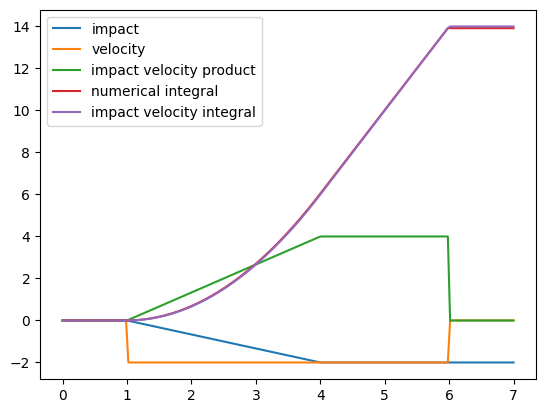

In [156]:
# This file is designed to contain a number of functions that will frequently be used for our impact processes.

# As our trading strategies are determenistic, we wish to calculate impact, trading costs, and costs due to impact all in closed form

# This decision means that everything that follows is very tedious...

import numpy as np

class TradingProcess:
    def __init__(self, Q_0, start_time, end_time, risk_aversion, times):
        self.Q_0 = Q_0
        self.start_time = start_time
        self.end_time = end_time
        self.risk_aversion = risk_aversion

        self.compute_volumes_and_velocities(times)


    def evaluate_volume(self, time):
        if time < self.start_time:
            return self.Q_0
        elif time > self.end_time:
             return 0
        
        else:
            if self.risk_aversion == 0: # If no risk aversion then we're under TWAP
                return (self.end_time - time) / (self.end_time - self.start_time) * self.Q_0
            
            else:
                return np.sinh(self.risk_aversion * (self.end_time - time)) / np.sinh(self.risk_aversion * (self.end_time - self.start_time)) * self.Q_0

        
    def evaluate_velocity(self, time):
        if time < self.start_time:
            return 0
        elif time > self.end_time:
             return 0
        
        else:
            if self.risk_aversion == 0: # If no risk aversion then we're under TWAP
                return -  self.Q_0 / (self.end_time - self.start_time)
            
            else:
                return - self.risk_aversion * np.cosh(self.risk_aversion * (self.end_time - time)) / np.sinh(self.risk_aversion * (self.end_time - self.start_time)) * self.Q_0

    def volume_vector(self, times):
        times_before_start = np.less(times , self.start_time)
        times_after_end = np.greater(times, self.end_time)
        times_between = np.ones(times.shape) - times_after_end - times_before_start

        if self.risk_aversion == 0: # If no risk aversion then we're under TWAP
            return (self.end_time - times) / (self.end_time - self.start_time) * self.Q_0 * times_between + times_before_start * self.Q_0
        else:
            return np.sinh(self.risk_aversion * (self.end_time - times)) / np.sinh(self.risk_aversion * (self.end_time - self.start_time)) * self.Q_0 * times_between + times_before_start * self.Q_0


    def velocity_vector(self, times):
        times_before_start = np.less(times , self.start_time)
        times_after_end = np.greater(times, self.end_time)
        times_between = np.ones(times.shape) - times_after_end - times_before_start

        if self.risk_aversion == 0: # If no risk aversion then we're under TWAP
            return -  self.Q_0 / (self.end_time - self.start_time) * times_between
            
        else:
            return - self.risk_aversion * np.cosh(self.risk_aversion * (self.end_time - times)) / np.sinh(self.risk_aversion * (self.end_time - self.start_time)) * self.Q_0 * times_between

    def compute_volumes_and_velocities(self, times):
        self.times = times
        self.volume = self.volume_vector(self.times)
        self.velocity = self.velocity_vector(self.times)

        return None

class ImpactProcess:

    def __init__(self, scale, decay, permanent_proportion):
        self.scale = scale # lambda
        self.decay = decay # beta
        self.permanent_proportion = permanent_proportion # p
        self.impact = 0
        self.times = 0

    
    def compute_impact(self, trade_process):
        """Just don't choose beta = gamma please... then I'll have to add that in"""
        times = trade_process.times
        self.times = times
        times_before_start = np.less(times , trade_process.start_time)
        times_after_end = np.greater(times, trade_process.end_time)
        times_between = np.ones(times.shape) - times_after_end - times_before_start

        if trade_process.risk_aversion == 0:
            I_0 = 0
            A = - (1 - self.permanent_proportion) / self.decay * (1 - np.exp(- self.decay * (times - trade_process.start_time)))
            B = - self.permanent_proportion * (times - trade_process.start_time)
            I_1 = (A + B) * self.scale * trade_process.Q_0 / (trade_process.end_time - trade_process.start_time) 
            
            C = - (1 - self.permanent_proportion) / (trade_process.end_time - trade_process.start_time) / self.decay * (np.exp(self.decay * (trade_process.end_time - times)) - np.exp(self.decay * (trade_process.start_time - times)))
            D = - self.permanent_proportion
            I_2 = (C + D) * trade_process.Q_0 * self.scale

            self.impact = I_0 * times_before_start + I_1 * times_between + I_2 * times_after_end

            return self.impact
        
        else:
            I_0 = 0

            A = np.exp(trade_process.risk_aversion * trade_process.end_time) / (self.decay - trade_process.risk_aversion) * (np.exp((self.decay - trade_process.risk_aversion) * times) - np.exp((self.decay - trade_process.risk_aversion) * trade_process.start_time))
            B = np.exp(- trade_process.risk_aversion * trade_process.end_time) / (self.decay + trade_process.risk_aversion) * (np.exp((self.decay + trade_process.risk_aversion) * times) - np.exp((self.decay + trade_process.risk_aversion) * trade_process.start_time))
            C = - trade_process.Q_0 * trade_process.risk_aversion * (1 - self.permanent_proportion) * self.scale * np.exp(-self.decay * times)
            D = 2 * np.sinh(trade_process.risk_aversion * (trade_process.end_time - trade_process.start_time))

            E = self.permanent_proportion * self.scale * trade_process.Q_0 * (np.sinh(trade_process.risk_aversion * (trade_process.end_time - times))/np.sinh(trade_process.risk_aversion *(trade_process.end_time - trade_process.start_time)) - 1)

            I_1 = C/D * (A + B) + E

            F = np.exp(trade_process.risk_aversion * trade_process.end_time) / (self.decay - trade_process.risk_aversion) * (np.exp((self.decay - trade_process.risk_aversion) * trade_process.end_time) - np.exp((self.decay - trade_process.risk_aversion) * trade_process.start_time))
            G = np.exp(- trade_process.risk_aversion * trade_process.end_time) / (self.decay + trade_process.risk_aversion) * (np.exp((self.decay + trade_process.risk_aversion) * trade_process.end_time) - np.exp((self.decay + trade_process.risk_aversion) * trade_process.start_time))
            I_2 = C/D * (F + G) - self.permanent_proportion * self.scale * trade_process.Q_0

            self.impact = I_0 * times_before_start + I_1 * times_between + I_2 * times_after_end

            return self.impact
        
    def impact_cost(self, impact_trades, cost_trades):
        
        times = cost_trades.times

        t_i = cost_trades.start_time
        T_i = cost_trades.end_time

        t_j = impact_trades.start_time
        T_j = impact_trades.end_time

        result = np.zeros(times.shape)

        # Our strategy is to compute each of the integrals in turn, and then add them on to the result

        # Limits for integral_1, unused but defined for completeness

        a_1 = np.max([0,t_i])
        b_1 = np.maximum(np.minimum(times, np.min([t_j, T_i])), a_1)


        # Limits for integral_2

        a_2 = np.max([0,t_i, t_j])
        b_2 = np.maximum(np.minimum(times, np.min([T_j, T_i])), a_2)


        # Limits for integral_3

        a_3 = np.max([0,t_i, T_j])
        b_3 = np.maximum(np.minimum(times, T_i), a_3)


        # Define terms as in Thesis for familiarity and to ease bug checking
        beta = self.decay
        lambdas = self.scale
        p = self.permanent_proportion
        
        gamma_i = cost_trades.risk_aversion
        Q_i = cost_trades.Q_0

        gamma_j = impact_trades.risk_aversion
        Q_j = impact_trades.Q_0
        
        
        # Risk Averse Impact
        if gamma_j > 0:
            X = -Q_j * gamma_j * (1-p) * lambdas / 2 / np.sinh(gamma_j * (T_j - t_j))

            # p = 0 terms

            A_j = X * np.exp(gamma_j * T_j) / (beta - gamma_j)

            B_j = X * np.exp(-gamma_j * T_j) / (beta + gamma_j)

            C_j = - X *( np.exp(-gamma_j * T_j) / (beta - gamma_j) * np.exp((beta - gamma_j) * t_j) + np.exp(-gamma_j * T_j) / (beta + gamma_j) * np.exp((beta+gamma_j) * t_j) )

            

            # p = 1 terms

            D_j = - p * lambdas * Q_j 

            J_j = p * lambdas * Q_j / np.sinh(gamma_j * (T_j - t_j))


            # Integral 3 terms

            E_j = - Q_j * gamma_j * (1-p) * lambdas / 2 / np.sinh(gamma_j * (T_j - t_j)) * (np.exp(gamma_j * T_j) / (beta - gamma_j) * (np.exp((beta - gamma_j) * T_j) - np.exp((beta - gamma_j) * t_j)) + np.exp(- gamma_j * T_j) / (beta + gamma_j) * (np.exp((beta + gamma_j) * T_j) - np.exp((beta + gamma_j) * t_j)))

            F_j = - Q_j * p * lambdas
        
            # Risk Averse Liquidation

            if gamma_i > 0:
                G_i = - Q_i * gamma_i * np.exp(gamma_i * T_i) / 2 / np.sinh(gamma_i * (T_i - t_i))

                H_i = - Q_i * gamma_i * np.exp(-gamma_i * T_i) / 2 / np.sinh(gamma_i * (T_i - t_i))

                L_i = - Q_i * gamma_i / np.sinh(gamma_i * (T_i - t_i))
                
                # Computing Integral 2
                if gamma_i != gamma_j:

                    # p = 1 terms

                    term_1 = - D_j * L_i / gamma_i * (np.sinh(gamma_i * (T_i - b_2)) - np.sinh(gamma_i * (T_i - a_2)))

                    term_2 = - J_j * L_i / 2 * (np.cosh((gamma_j*T_j + gamma_i*T_i) - (gamma_j + gamma_i) * b_2) / (gamma_j + gamma_i) - np.cosh((gamma_j*T_j + gamma_i*T_i) - (gamma_j + gamma_i) * a_2) / (gamma_j + gamma_i) + np.cosh(gamma_j * T_j - gamma_i * T_i - (gamma_j - gamma_i) * b_2)/(gamma_j - gamma_i) - np.cosh(gamma_j * T_j - gamma_i * T_i - (gamma_j - gamma_i) * a_2)/(gamma_j - gamma_i))


                    # p = 0 terms

                    term_3 = - A_j * G_i / (gamma_j + gamma_i) * (np.exp(-(gamma_j + gamma_i) * b_2) - np.exp(-(gamma_j + gamma_i) * a_2))

                    term_4 = A_j * H_i / (gamma_j - gamma_i) * (np.exp((gamma_i - gamma_j) * b_2) - np.exp((gamma_i - gamma_j) * a_2))

                    term_5 = B_j * G_i / (gamma_j - gamma_i) * (np.exp((gamma_j - gamma_i) * b_2) - np.exp((gamma_j - gamma_i) * a_2))

                    term_6 = B_j * H_i / (gamma_i + gamma_j) * (np.exp((gamma_i + gamma_j) * b_2) - np.exp((gamma_i + gamma_j) * a_2))

                    term_7 = C_j * H_i / (gamma_i - beta) * (np.exp((gamma_i - beta) * b_2) - np.exp((gamma_i - beta) *a_2))

                    term_8 = - C_j * G_i / (beta + gamma_i) * (np.exp(-(beta + gamma_i) * b_2) - np.exp(-(beta + gamma_i) * a_2))



                    integral_2 = term_1 + term_2 + term_3 + term_4 + term_5 + term_6 + term_7 + term_8

                    

                if gamma_i == gamma_j:

                    # p = 1 terms

                    term_1 = - D_j * L_i / gamma_i * (np.sinh(gamma_i * (T_i - b_2)) - np.sinh(gamma_i * (T_i - a_2)))

                    term_2 = J_j * L_i / 2 * np.sinh(gamma_i * (T_j - T_i)) * (b_2 - a_2)
                    
                    term_3 = -J_j * L_i / 4 / gamma_i * (np.cosh(gamma_i * (T_i + T_j - 2 * b_2)) - np.cosh(gamma_i * (T_i + T_j - 2 * a_2)))

                    integral_2 = term_1 + term_2 + term_3

                    # p = 0 terms

                # Integral three

                term_1 = - E_j * G_i / (beta + gamma_i) * (np.exp(-(beta + gamma_i) * b_3) - np.exp(-(beta + gamma_i) * a_3))
                term_2 = E_j * H_i / (gamma_i - beta) * (np.exp((gamma_i - beta) * b_3) - np.exp((gamma_i - beta) * a_3))
                term_3 = - F_j * G_i / gamma_i * (np.exp(- gamma_i * b_3) - np.exp(- gamma_i * a_3))
                term_4 = F_j * H_i / gamma_i * (np.exp(gamma_i * b_3) - np.exp(gamma_i * a_3))

                integral_3 = term_1 + term_2 + term_3 + term_4

                result = integral_2 + integral_3

            # TWAP Liquidation
            elif gamma_i == 0:

                K_i = - Q_i / (T_i - t_i)

                # Integral 2

                term_1 = - A_j / gamma_j * (np.exp(-gamma_j * b_2) - np.exp(-gamma_j * a_2))
                term_2 = B_j / gamma_j * (np.exp(gamma_j  * b_2) - np.exp(gamma_j * a_2))
                term_3 = - C_j / beta * (np.exp(- beta * b_2) - np.exp( - beta * a_2))
                term_4 = D_j * (b_2 - a_2)

                integral_2 = K_i * (term_1 + term_2 + term_3 + term_4)

                # Integral 3

                term_1 = - E_j / beta * (np.exp(-beta * b_3) - np.exp(-beta * a_3))
                term_2 = F_j * (b_3 - a_3)

                integral_3 = K_i * (term_1 + term_2)

                result = integral_2 + integral_3

        # TWAP Impact
        elif gamma_j == 0:

            A_j = - Q_j * (1-p) * lambdas / (T_j - t_j) / beta + Q_j * p * lambdas * t_j / (T_j - t_j)

            B_j =  - Q_j * p * lambdas / (T_j - t_j)

            C_j =  Q_j * (1-p) * lambdas * np.exp(-beta * t_j) / (T_j - t_j) / beta

            D_j = -Q_j * p * lambdas

            E_j = - Q_j * (1-p) * lambdas / (T_j - t_j) / beta * (np.exp(beta * T_j) - np.exp(beta * t_j))


            # Risk Averse Liquidation

            if gamma_i > 0:
                
                G_i = -Q_i * gamma_i * np.exp(gamma_i * T_i) / 2 / np.sinh(gamma_i * (T_i - t_i))

                H_i = -Q_i * gamma_i * np.exp(-gamma_i * T_i) / 2 / np.sinh(gamma_i * (T_i - t_i))

                # Integral 2

                term_1 = - A_j * G_i / gamma_i * (np.exp(-gamma_i * b_2) - np.exp(-gamma_i * a_2))

                term_2 = A_j * H_i / gamma_i * (np.exp(gamma_i * b_2) - np.exp(gamma_i * a_2))

                term_3 = B_j * G_i * (- b_2 * np.exp(-gamma_i * b_2) / gamma_i - np.exp(-gamma_i * b_2) / gamma_i / gamma_i + a_2 * np.exp(-gamma_i * a_2) / gamma_i + np.exp(-gamma_i * a_2) / gamma_i / gamma_i)

                term_4 = B_j * H_i * (b_2 * np.exp(gamma_i * b_2) / gamma_i - np.exp(gamma_i * b_2) / gamma_i / gamma_i - a_2 * np.exp(gamma_i * a_2) / gamma_i + np.exp(gamma_i * a_2) / gamma_i /gamma_i)

                term_5 = - C_j * G_i / (beta + gamma_i) * (np.exp(-(beta + gamma_i) * b_2) - np.exp(-(beta + gamma_i) * a_2))

                term_6 = C_j * H_i / (gamma_i - beta) * (np.exp((gamma_i - beta) * b_2) - np.exp((gamma_i - beta) * a_2))

                integral_2 = term_1 + term_2 + term_3 + term_4 + term_5 + term_6

                # Integral 3

                term_1 = - D_j * G_i / gamma_i * (np.exp(-gamma_i * b_3) - np.exp(- gamma_i * a_3))

                term_2 = D_j * H_i / gamma_i * (np.exp(gamma_i * b_3) - np.exp(gamma_i * a_3))

                term_3 = -E_j * G_i / (beta + gamma_i) * (np.exp(-(beta + gamma_i) * b_3) - np.exp(-(beta + gamma_i) * a_3))

                term_4 = E_j * H_i / (gamma_i - beta) * (np.exp((gamma_i - beta) * b_3) - np.exp((gamma_i - beta) * a_3))

                integral_3 = term_1 + term_2 + term_3 + term_4

                result = integral_2 + integral_3

            # TWAP Liquidation
            if gamma_i == 0:

                K_i = - Q_i / (T_i - t_i)

                # Integral 2

                term_1 = A_j * K_i * (b_2 - a_2)

                term_2 = B_j * K_i / 2 * (b_2 * b_2 - a_2 * a_2)

                term_3 = -C_j * K_i / beta * (np.exp(-beta * b_2) - np.exp(-beta * a_2))

                integral_2 = term_1 + term_2 + term_3

                # Integral 3

                term_1 = D_j * K_i * (b_3 - a_3)

                term_2 = - E_j * K_i / beta * (np.exp(-beta * b_3 - np.exp(-beta * a_3)))

                integral_3 = term_1 + term_2

                print(integral_2)

                print(integral_3)

                result = integral_2 + integral_3


        return result
        

class TradingCost:
    def __init__(self, phi):
        self.phi = phi

    def compute_costs(self, trading_process_1, trading_process_2):
        "Make sure both trading processes have their times set before calling"
        times = trading_process_1.times
        lower_limit = np.max([0, trading_process_1.start_time, trading_process_2.start_time])
        upper_limit = np.minimum(np.min([trading_process_1.end_time, trading_process_2.end_time]), times)
        times_after_lower_limit = np.greater(times, lower_limit)

        if (trading_process_1.risk_aversion == 0) and (trading_process_2.risk_aversion == 0): # TWAP and TWAP
            return - self.phi * ((upper_limit - lower_limit) * trading_process_1.Q_0 * trading_process_2.Q_0 / (trading_process_1.end_time - trading_process_1.start_time) / (trading_process_2.end_time - trading_process_2.start_time) * times_after_lower_limit)

        elif (trading_process_1.risk_aversion == 0): # TWAP and Risk Averse
            A = - trading_process_1.Q_0 * trading_process_2.Q_0 / (trading_process_1.end_time - trading_process_1.start_time) / np.sinh(trading_process_2.risk_aversion * (trading_process_2.end_time - trading_process_2.start_time))  

            return - self.phi * ( A * (np.sinh(trading_process_2.risk_aversion * (trading_process_2.end_time - upper_limit)) - np.sinh(trading_process_2.risk_aversion * (trading_process_2.end_time - lower_limit))) ) * times_after_lower_limit
        
        elif (trading_process_2.risk_aversion == 0): # Risk Averse and TWAP
            A = - trading_process_2.Q_0 * trading_process_1.Q_0 / (trading_process_2.end_time - trading_process_2.start_time) / np.sinh(trading_process_1.risk_aversion * (trading_process_1.end_time - trading_process_1.start_time))  

            return - self.phi * ( A * (np.sinh(trading_process_1.risk_aversion * (trading_process_1.end_time - upper_limit)) - np.sinh(trading_process_1.risk_aversion * (trading_process_1.end_time - lower_limit))) ) *times_after_lower_limit

        elif (trading_process_1.risk_aversion != trading_process_2.risk_aversion):
            A = np.sinh(trading_process_1.risk_aversion * trading_process_1.end_time + trading_process_2.risk_aversion * trading_process_2.end_time - (trading_process_1.risk_aversion + trading_process_2.risk_aversion) * upper_limit) / (trading_process_1.risk_aversion + trading_process_2.risk_aversion)
            B = np.sinh(trading_process_1.risk_aversion * trading_process_1.end_time - trading_process_2.risk_aversion * trading_process_2.end_time - (trading_process_1.risk_aversion - trading_process_2.risk_aversion) * upper_limit) / (trading_process_1.risk_aversion - trading_process_2.risk_aversion)

            D = np.sinh(trading_process_1.risk_aversion * trading_process_1.end_time + trading_process_2.risk_aversion * trading_process_2.end_time - (trading_process_1.risk_aversion + trading_process_2.risk_aversion) * lower_limit) / (trading_process_1.risk_aversion + trading_process_2.risk_aversion)
            E = np.sinh(trading_process_1.risk_aversion * trading_process_1.end_time - trading_process_2.risk_aversion * trading_process_2.end_time - (trading_process_1.risk_aversion - trading_process_2.risk_aversion) * lower_limit) / (trading_process_1.risk_aversion - trading_process_2.risk_aversion)

            C = trading_process_1.Q_0 * trading_process_2.Q_0 * trading_process_1.risk_aversion * trading_process_2.risk_aversion / np.sinh(trading_process_1.risk_aversion * (trading_process_1.end_time - trading_process_1.start_time)) / np.sinh(trading_process_2.risk_aversion * (trading_process_2.end_time - trading_process_2.start_time))

            return - self.phi * (- C / 2 * (A + B - D - E) * times_after_lower_limit)
        
        else:
            A = np.sinh(trading_process_1.risk_aversion * ((trading_process_1.end_time + trading_process_2.end_time) - 2 * upper_limit )) / 2 / trading_process_1.risk_aversion - np.cosh(trading_process_1.risk_aversion * (trading_process_1.end_time - trading_process_2.end_time)) * upper_limit
            B = np.sinh(trading_process_1.risk_aversion * ((trading_process_1.end_time + trading_process_2.end_time) - 2 * lower_limit )) / 2 / trading_process_1.risk_aversion - np.cosh(trading_process_1.risk_aversion * (trading_process_1.end_time - trading_process_2.end_time)) * lower_limit


            C = trading_process_1.Q_0 * trading_process_2.Q_0 * trading_process_1.risk_aversion * trading_process_2.risk_aversion / np.sinh(trading_process_1.risk_aversion * (trading_process_1.end_time - trading_process_1.start_time)) / np.sinh(trading_process_2.risk_aversion * (trading_process_2.end_time - trading_process_2.start_time))
            return - self.phi * ( - C / 2 * (A - B) ) * times_after_lower_limit 


#########################################################################

import matplotlib.pyplot as plt

maturity = 7

steps = 200

times = np.linspace(0, maturity, steps)

impact = ImpactProcess(0.5, 4, 1)

process_1 = TradingProcess(4, 1, 4, 0, times)

process_2 = TradingProcess(10, 1, 6,0, times)

trading_costs = TradingCost(0.1)

process_1_and_2_costs = impact.impact_cost(process_1, process_2)

plt.plot(times, impact.compute_impact(process_1), label = 'impact')

plt.plot(times, process_2.velocity, label = 'velocity')

product = impact.compute_impact(process_1) * process_2.velocity

plt.plot(times, product, label = 'impact velocity product')

numerical_integral = product.cumsum() * maturity/steps

plt.plot(times, numerical_integral, label = 'numerical integral')

plt.plot(times, process_1_and_2_costs, label = 'impact velocity integral')

plt.legend()

plt.show()


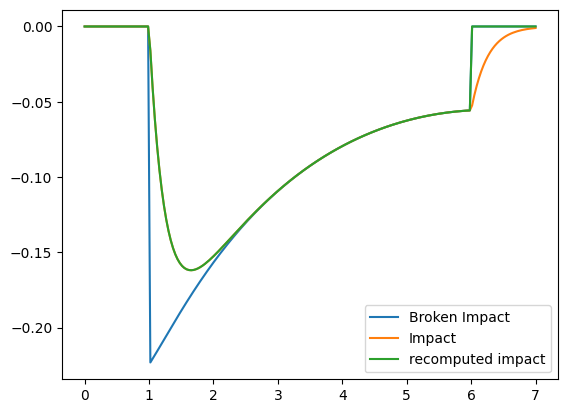

In [158]:
times = np.linspace(0, maturity, steps)




impact_trades = TradingProcess(4, 1, 6, 0.4, times)
impact = ImpactProcess(0.5, 4, 0)

t_j = impact_trades.start_time
T_j = impact_trades.end_time

interest_period = np.less(times, T_j) * np.greater(times, t_j)

beta = impact.decay
lambdas = impact.scale
p = impact.permanent_proportion

gamma_j = impact_trades.risk_aversion
Q_j = impact_trades.Q_0

X = -Q_j * gamma_j * (1-p) * lambdas / 2 / np.sinh(gamma_j * (T_j - t_j))

A_j = X * np.exp(gamma_j * T_j) / (beta - gamma_j)

B_j = X * np.exp(-gamma_j * T_j) / (beta + gamma_j)

C_j = - X *( np.exp(-gamma_j * T_j) / (beta - gamma_j) * np.exp((beta - gamma_j) * t_j) + np.exp(-gamma_j * T_j) / (beta + gamma_j) * np.exp((beta+gamma_j) * t_j) )

D_j = - p * lambdas * Q_j 

E_j = p * lambdas * Q_j / np.sinh(gamma_j * (T_j - t_j))

recomputed_impact = -Q_j * gamma_j * (1-p) * lambdas * np.exp(-beta * times) / 2 /np.sinh(gamma_j * (T_j - t_j)) * (np.exp(gamma_j * T_j) / (beta-gamma_j) * (np.exp((beta - gamma_j) * times) - np.exp((beta - gamma_j) * t_j)) + np.exp(-gamma_j * T_j) / (beta + gamma_j) * (np.exp((beta + gamma_j) * times) - np.exp((beta + gamma_j) * t_j))) + p * lambdas * Q_j * (np.sinh(gamma_j * (T_j - times)) / np.sinh(gamma_j * (T_j - t_j)) - 1) 

plt.plot(times, (A_j * np.exp(-gamma_j * times) + B_j * np.exp(gamma_j * times) + C_j * np.exp(- beta * times) + D_j + E_j * np.sinh(gamma_j * (T_j - times)))*interest_period, label = "Broken Impact")
plt.plot(times, impact.compute_impact(impact_trades), label = "Impact")
plt.plot(times, recomputed_impact * interest_period, label = "recomputed impact")
plt.legend()
plt.show()